In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import numpy as np 
import itertools
import scipy 
import math
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)
pi = torch.tensor(np.pi,dtype=torch.float64)

from utils import SquareMesh2D_points
from utils import s2_uniform_grid_init
from utils import output_convergence_order_l2
from utils import plot_err_convergence
from model import ShallowReLUkFitter
from model import PouShallowReLUkFitter

In [2]:
def run_exp(k, m, l, nmin=6, nmax=13):
    x_train = SquareMesh2D_points(0,1,200)
    x_test = SquareMesh2D_points(0,1,150)

    if l == 0:
        # Global fitter
        neuron_num_arr= np.array([2**i for i in range(nmin, nmax)]) 
        neuron_arr = []
        rel_errl2_arr = []
        for i, n in enumerate(neuron_num_arr):
            ws, bs = s2_uniform_grid_init(n, k=k)
            fitter = ShallowReLUkFitter(
                ws, bs, x_train, k=k, m1=m, m2=m)
            if fitter.n > 2500:
                break
            fitter.solve()
            rel_errl2 = fitter.eval(x_test)
            neuron_arr.append(fitter.n)
            rel_errl2_arr.append(rel_errl2)
            print('num neuron : {:} - rel l2 : {:.4e}'.format(fitter.n, rel_errl2))
    else:
        neuron_num_arr= np.array([2**i for i in range(nmin, nmax)]) 
        neuron_arr = []
        rel_errl2_arr = []
        for i, n in enumerate(neuron_num_arr):
            ws, bs = s2_uniform_grid_init(n, k=k)
            fitter = PouShallowReLUkFitter(
                ws, bs, x_train, l=l, k=k, m1=m, m2=m)
            if fitter.J * fitter.n > 2500:
                break 
            fitter.solve()
            rel_errl2 = fitter.eval(x_test)
            neuron_arr.append(fitter.n*fitter.J)
            rel_errl2_arr.append(rel_errl2)
            print('local {:} num neuron : {:} - rel l2 : {:.4e}'.format(fitter.J, fitter.n*fitter.J, rel_errl2))

    return np.array(neuron_arr), np.array(rel_errl2_arr)

In [3]:
def plot_err_convergence_levels(relu_k, d, neuron_list, err_list, levels, title):
    """
    Plot L2 error convergence for multiple levels l.
    
    Parameters:
        relu_k : int
            Degree of ReLU (k)
        d : int
            Input dimension
        neuron_list : list of arrays
            Each element: actual_neuron_arr for one level l
        err_list : list of arrays
            Each element: mean_err_l2_arr for one level l
        levels : list
            List of level parameters corresponding to neuron_list / err_list
        title : str
            Plot title
    """
    plt.figure(figsize=(7,5))
    L2J = {1:4, 2:9, 3:25}

    for neurons, err, l in zip(neuron_list, err_list, levels):
        # compute reference line for this level (optional)
        if l == 0:
            optimal_rate = 1/2 + (2 * relu_k + 1)/(2*d)
            ref = err[0] * neurons[0]**optimal_rate * neurons**(-optimal_rate)
            plt.plot(neurons, ref, '--', label=f'slope = -{optimal_rate:.2f}')
            plt.plot(neurons, err, '.-', label=f'ReLU$^{relu_k}$', linewidth=2)
        else:
            plt.plot(neurons, err, '.-', label=f'J = {L2J[l]}, ReLU$^{relu_k}$', linewidth=2)
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel("Number of neurons n")
    plt.ylabel("rel $L^2$ error")
    plt.title(title)
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()


num neuron : 3 - rel l2 : 9.7029e-01
num neuron : 6 - rel l2 : 6.7873e-01
num neuron : 11 - rel l2 : 1.9335e-01
num neuron : 20 - rel l2 : 1.1159e-01
num neuron : 34 - rel l2 : 2.4791e-02
num neuron : 60 - rel l2 : 8.1407e-03
num neuron : 116 - rel l2 : 2.2521e-03
num neuron : 230 - rel l2 : 5.7516e-04
num neuron : 448 - rel l2 : 2.2161e-04
num neuron : 900 - rel l2 : 6.1308e-05
num neuron : 1800 - rel l2 : 1.6816e-05
local 4 num neuron : 12 - rel l2 : 3.4073e-01
local 4 num neuron : 24 - rel l2 : 2.0839e-01
local 4 num neuron : 44 - rel l2 : 4.6933e-02
local 4 num neuron : 80 - rel l2 : 2.7666e-02
local 4 num neuron : 136 - rel l2 : 1.1984e-02
local 4 num neuron : 240 - rel l2 : 2.9913e-03
local 4 num neuron : 464 - rel l2 : 9.5470e-04
local 4 num neuron : 920 - rel l2 : 2.3298e-04
local 4 num neuron : 1792 - rel l2 : 9.5789e-05
local 9 num neuron : 27 - rel l2 : 4.3673e-01
local 9 num neuron : 54 - rel l2 : 1.4882e-01
local 9 num neuron : 99 - rel l2 : 1.2161e-02
local 9 num neuron :

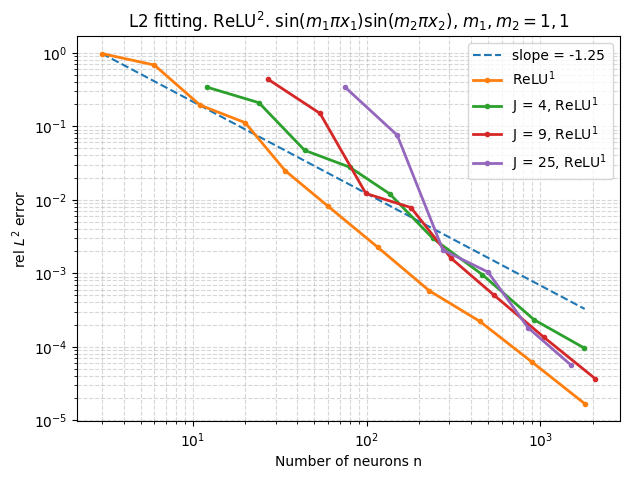

In [ ]:
k = 2
m = 1
l_list = [0, 1, 2, 3]
neurons_list = []
errs_list = []
for l in l_list:
    neurons, errs = run_exp(k, m, l, 2, 13)
    neurons_list.append(neurons)
    errs_list.append(errs)



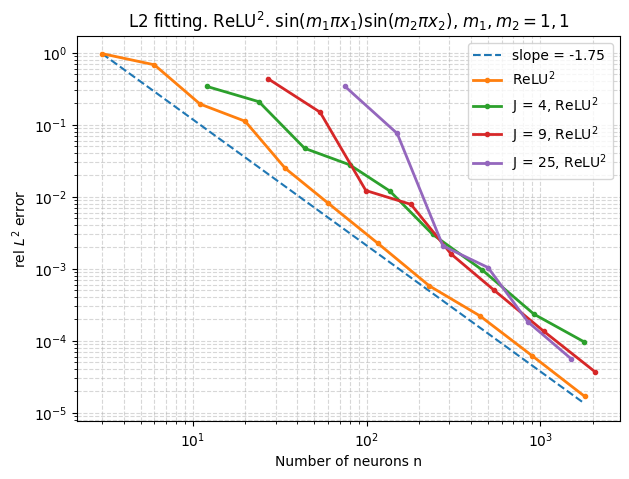

In [ ]:
title = "L2 fitting. ReLU$^{}$. $u(x_1, x_2) = \sin(m_1\pi x_1) \sin(m_2\pi x_2)$, $m_1,m_2 = {}, {}$".format(k, m, m)
plot_err_convergence_levels(k, 2, neurons_list, errs_list, l_list, title)